In [98]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import rioxarray as rxa
sns.set_theme()

from shapely import box, Polygon
import geopandas as gpd
import pandas as pd
import rasterio
import math
from datetime import datetime

from pathlib import Path

# ====== import my own functions =========
import sys
import os
project_root = str(Path(os.getcwd()).parent)

if project_root not in sys.path:
    sys.path.append(project_root)

%load_ext autoreload
%autoreload 2
# from scripts.layers import assemble_data, get_uavsar_coherence, get_uavsar_incidence, get_nlcd_layers
from scripts.layers import *
from scripts.validation import validate_date_pairs, make_reference_grid

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Assemble metadata info 

In [2]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'
file_info = pd.read_parquet(data_dir + 'coherence_files_overview.parquet')
file_info

,filename,file_type,flight_path,flight_num,date_reference,date_secondary,polarization,segment,absolute_path
0,lowman_05208_20002_006_200131_L090HH_01_BU.ann,ann_slc,lowman,05208,200131,NaN,NaN,NaN,/bsuhome/julialober/scratch/coherence_data/uav...
1,lowman_05208_20002_006_200131_L090HH_01_BU_s1_...,raw_slc,lowman,05208,200131,NaN,NaN,s1,/bsuhome/julialober/scratch/coherence_data/uav...
2,lowman_05208_01_BU_s1_2x8.lkv,lkv,lowman,05208,NaN,NaN,NaN,s1,/bsuhome/julialober/scratch/coherence_data/uav...
3,lowman_05208_01_BU_s1_2x8.llh,llh,lowman,05208,NaN,NaN,NaN,s1,/bsuhome/julialober/scratch/coherence_data/uav...
4,lowman_05208_21009_005_210203_L090HV_01_BU_s3_...,raw_slc,lowman,05208,210203,NaN,NaN,s3,/bsuhome/julialober/scratch/coherence_data/uav...
...,...,...,...,...,...,...,...,...,...
3789,uticam_21003_210115_210223_VV_s1_w5_int_coh.tif,int_pair,uticam,21003,210115,210223,VV,s1,/bsuhome/julialober/scratch/coherence_data/uav...
3790,uticam_21003_210115_210120_VV_s1_w5_int_coh.tif,int_pair,uticam,21003,210115,210120,VV,s1,/bsuhome/julialober/scratch/coherence_data/uav...
3791,uticam_21003_210120_HV-VH_s1_w5_crosspol_coh.tif,crosspol,uticam,21003,210120,NaN,HV-VH,s1,/bsuhome/julialober/scratch/coherence_data/uav...
3792,uticam_21003_210115_210120_HH_s1_w13_int_coh.tif,int_pair,uticam,21003,210115,210120,HH,s1,/bsuhome/julialober/scratch/coherence_data/uav...


In [3]:
meta = file_info[file_info['flight_path'] == 'rockmt']
meta = meta[meta['flight_num'] == '32109'] # this is the only path useful for my chosen site
summary_df = meta.pivot_table(index=['flight_path', 'flight_num'], 
                                columns='file_type', 
                                aggfunc='size', 
                                fill_value=0)
display(summary_df.join(meta.groupby(['flight_path', 'flight_num'])[['polarization', 'segment']].nunique().add_prefix('unique_')))

,,ann_slc,crosspol,geo_slc,int_pair,lkv,llh,raw_slc,unique_polarization,unique_segment
flight_path,flight_num,,,,,,,,,
rockmt,32109,32,8,32,28,1,1,32,2,1


In [8]:
POL = 'VV'
int_pairs = meta[meta['file_type'] == 'int_pair']
int_pairs = int_pairs[int_pairs['polarization'] == POL]
print(f'Using only {POL} polarization.')

# establish an output directory 
fp_dest = data_dir + 'stacks/rockmt'
print(f'Output Zarr directory: {fp_dest}')

# get flight ids 
flight_ids = meta['flight_num'].unique()
print(f'Flight numbers: {flight_ids}')

# get all date pairs 
date_pairs_int = list(zip(int_pairs['date_reference'], int_pairs['date_secondary']))
dates = [(f"20{date[0]}", f"20{date[1]}") for date in date_pairs_int]
print(f'Number of date pairs: {len(dates)}')

# get bounding box 
filenames = [int_pairs[int_pairs['flight_num'] == f]['absolute_path'].iloc[0] for f in flight_ids]
all_bounds = [rasterio.open(f).bounds for f in filenames]
aoi = box(
    min(b[0] for b in all_bounds), # min left
    min(b[1] for b in all_bounds), # min bottom
    max(b[2] for b in all_bounds), # max right
    max(b[3] for b in all_bounds)  # max top
)

# small box for RMNP 
coords = [
    (-105.8462033234742, 40.45931483103253),
    (-105.7838780833698, 40.40425021552515),
    (-105.7136429921721, 40.44535712159221),
    (-105.7725118718758, 40.50104010750601),
    (-105.8462033234742, 40.45931483103253)
]

# Create the 2D Polygon
aoi = Polygon(coords)

print(f'AOI bounding box: {aoi}')

Using only VV polarization.
Output Zarr directory: /bsuhome/julialober/scratch/coherence_data/stacks/meta
Flight numbers: <ArrowStringArray>
['32109']
Length: 1, dtype: str
Number of date pairs: 28
AOI bounding box: POLYGON ((-105.8462033234742 40.45931483103253, -105.7838780833698 40.40425021552515, -105.7136429921721 40.44535712159221, -105.7725118718758 40.50104010750601, -105.8462033234742 40.45931483103253))


In [11]:
METRES_PER_DEGREE_AT_45_LAT: float = 111320.0 * math.cos(math.radians(45.0))
res = 30 
res_grid = res / METRES_PER_DEGREE_AT_45_LAT
ref_grid = make_reference_grid(aoi=aoi, crs='EPSG:4326', resolution=res_grid)

In [13]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True 
)

In [14]:
cohs = get_uavsar_coherence(
    tile_aoi=aoi,
    date_pairs=validate_date_pairs(dates),
    flight_ids=flight_ids,
    crs='EPSG:4326',
    tile_ref_grid=ref_grid,
    fp=data_dir + 'uavsar_cohs/rockmt/',
)
cohs

In [20]:
inc = get_uavsar_incidence(
    tile_aoi=aoi,
    flight_ids=flight_ids,
    fp_inc=data_dir + 'inc_angle/',
    tile_ref_grid=ref_grid,
    crs='EPSG:4326',
)
inc

<xarray.DataArray 'incidence_angle' (flight_id: 1, y: 254, x: 348)> Size: 707kB
array([[[75.3502977 , 72.76340734, 73.45747425, ...,         nan,
                 nan,         nan],
        [76.55517317, 77.80170547, 77.09085555, ...,         nan,
                 nan,         nan],
        [81.33080164, 81.08511489, 81.35761867, ...,         nan,
                 nan,         nan],
        ...,
        [57.40173157, 58.42284833, 60.15966098, ..., 58.24903214,
         60.75062657, 60.21875638],
        [56.80649217, 60.68182636, 62.89412929, ..., 57.6300161 ,
         58.95499617, 59.43155325],
        [59.96196126, 62.48721595, 66.26069072, ..., 57.139743  ,
         58.53354426, 59.89894807]]], shape=(1, 254, 348))
Coordinates:
  * flight_id    (flight_id) StringDType(na_object=nan) 16B '32109'
  * y            (y) float64 2kB 40.5 40.5 40.5 40.5 ... 40.41 40.41 40.4 40.4
  * x            (x) float64 3kB -105.8 -105.8 -105.8 ... -105.7 -105.7 -105.7
    spatial_ref  int64 8B 0

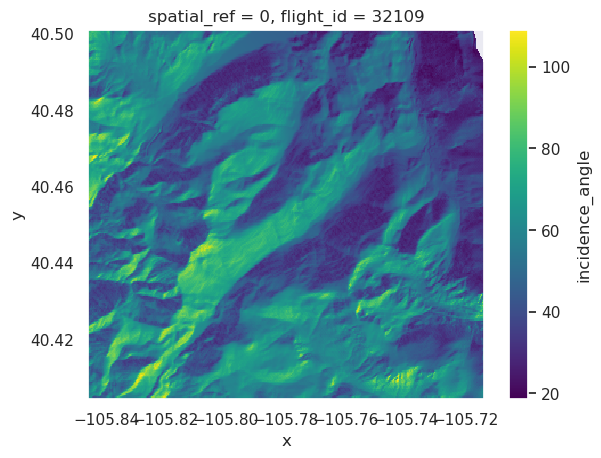

In [28]:
inc.plot()

In [30]:
nlcd = get_nlcd_layers(
    tile_aoi=aoi,
    crs='EPSG:4326',
    years={'cover': [2021], 'canopy': [2021]},
    tile_ref_grid=ref_grid,
)
nlcd

/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(


<xarray.Dataset> Size: 447kB
Dimensions:      (x: 348, y: 254)
Coordinates:
  * x            (x) float64 3kB -105.8 -105.8 -105.8 ... -105.7 -105.7 -105.7
  * y            (y) float64 2kB 40.5 40.5 40.5 40.5 ... 40.41 40.41 40.4 40.4
    spatial_ref  int64 8B 0
Data variables:
    cover_2021   (y, x) uint8 88kB 127 127 127 127 127 ... 127 127 127 127 127
    canopy_2021  (y, x) float32 354kB nan nan nan nan nan ... nan nan nan nan
Attributes:
    TIFFTAG_XRESOLUTION:     1
    TIFFTAG_YRESOLUTION:     1
    TIFFTAG_RESOLUTIONUNIT:  1 (unitless)
    AREA_OR_POINT:           Area
    _FillValue:              255
    scale_factor:            1.0
    add_offset:              0.0

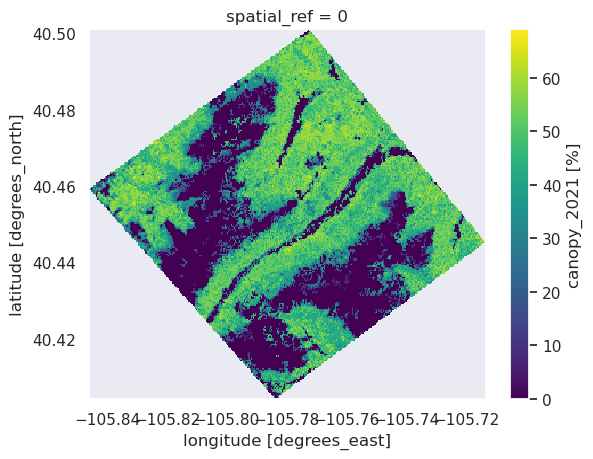

In [27]:
nlcd['canopy_2021'].plot()

In [31]:
data = assemble_data(
    tile_aoi=aoi,
    date_pairs=dates,
    flight_ids=flight_ids,
    include_layers=['coh', 'incidence', 'dem', 'nlcd', 'aorc'], 
    fp_coh=data_dir + 'uavsar_cohs/rockmt',
    fp_inc=data_dir + 'inc_angle/',
    crs='EPSG:4326',
    res=30,
) 

2026-06-01 13:15:35,252 - INFO - Starting tile data assembly for flights <ArrowStringArray>
['32109']
Length: 1, dtype: str
2026-06-01 13:15:39,322 - INFO - Tile: loaded coherence for flights <ArrowStringArray>
['32109']
Length: 1, dtype: str in 4.053 seconds.
2026-06-01 13:15:39,493 - INFO - Tile: loaded incidence angles for flights <ArrowStringArray>
['32109']
Length: 1, dtype: str in 0.170 seconds.
2026-06-01 13:15:39,664 - INFO - boto3 not available, falling back to a DummySession.
2026-06-01 13:15:41,575 - INFO - Tile: got DEM in 2.082 seconds.
/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_d

In [49]:
single_year_pairs = [
    f'{p[0][2:]}_{p[1][2:]}' for p in dates 
    if p[0][2:4] == p[1][2:4]
]

print(single_year_pairs)

data = data.sel(pair=single_year_pairs)

['210127_210303', '200219_200312', '210203_210310', '210310_210322', '210203_210322', '200212_200312', '210303_210322', '210303_210310', '210127_210310', '210203_210303', '210127_210322', '210127_210203', '200212_200219']


In [50]:
data = data.where(data['elevation'].notnull())

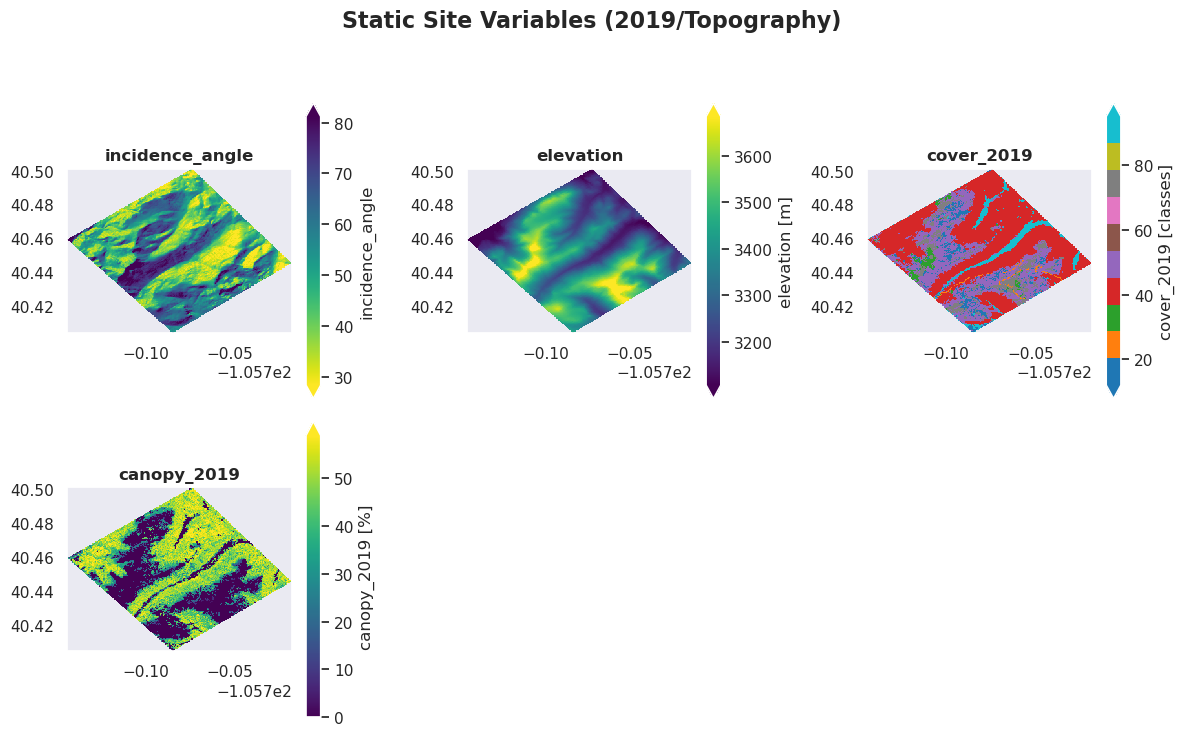

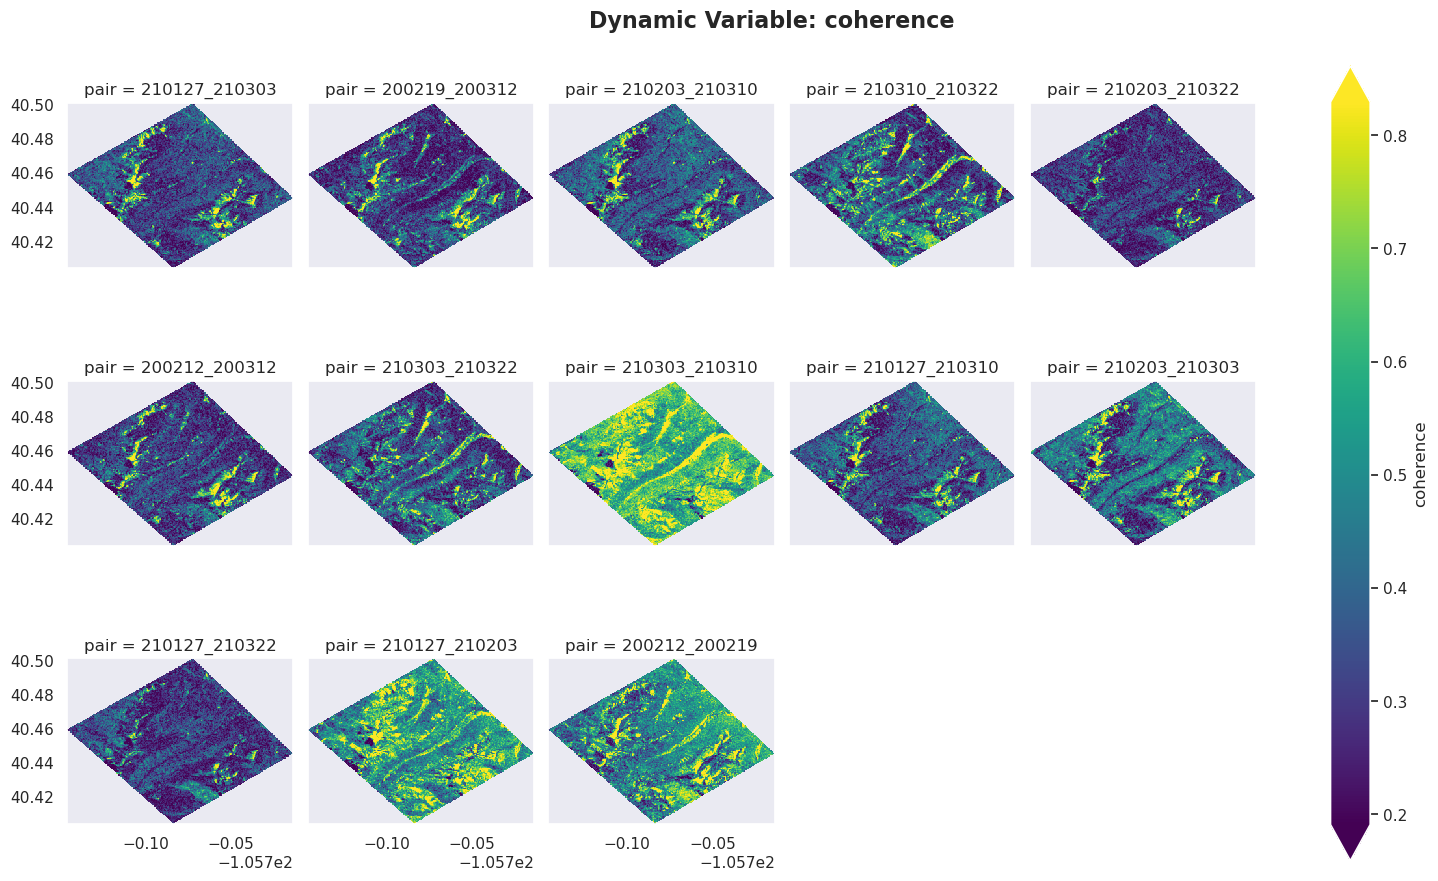

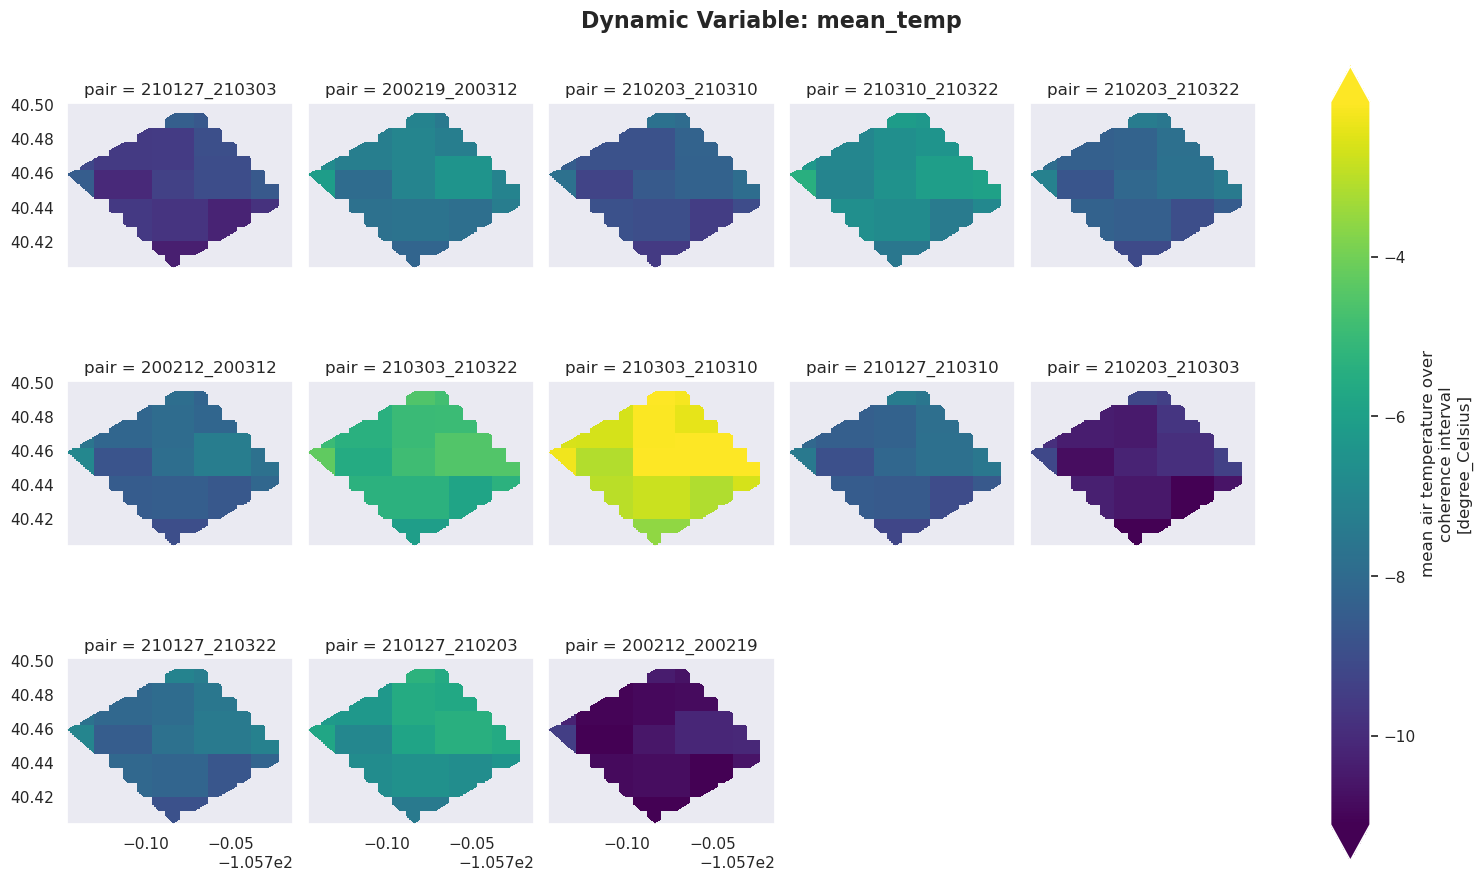

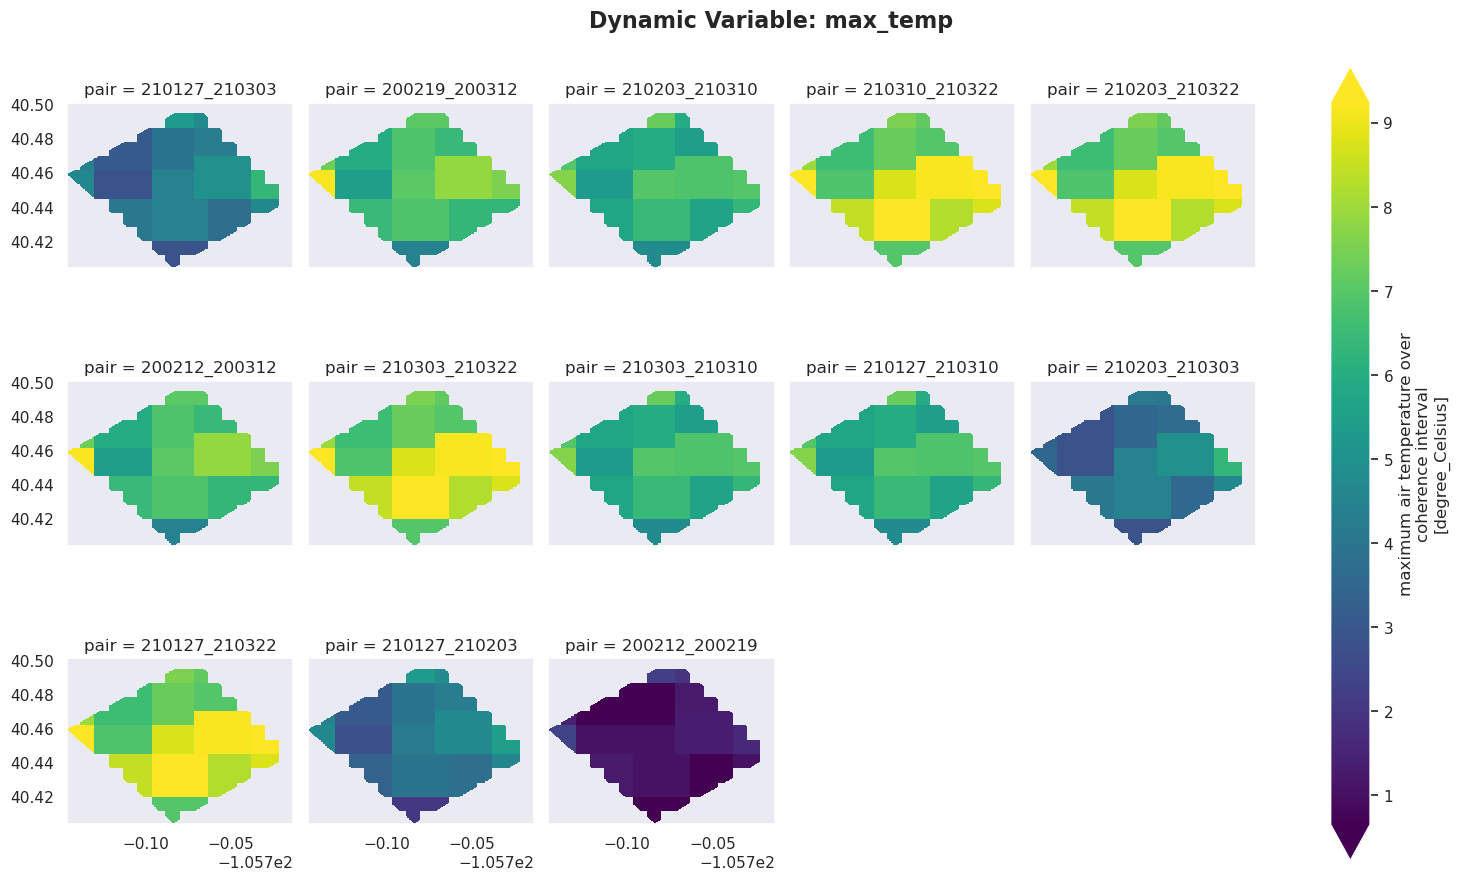

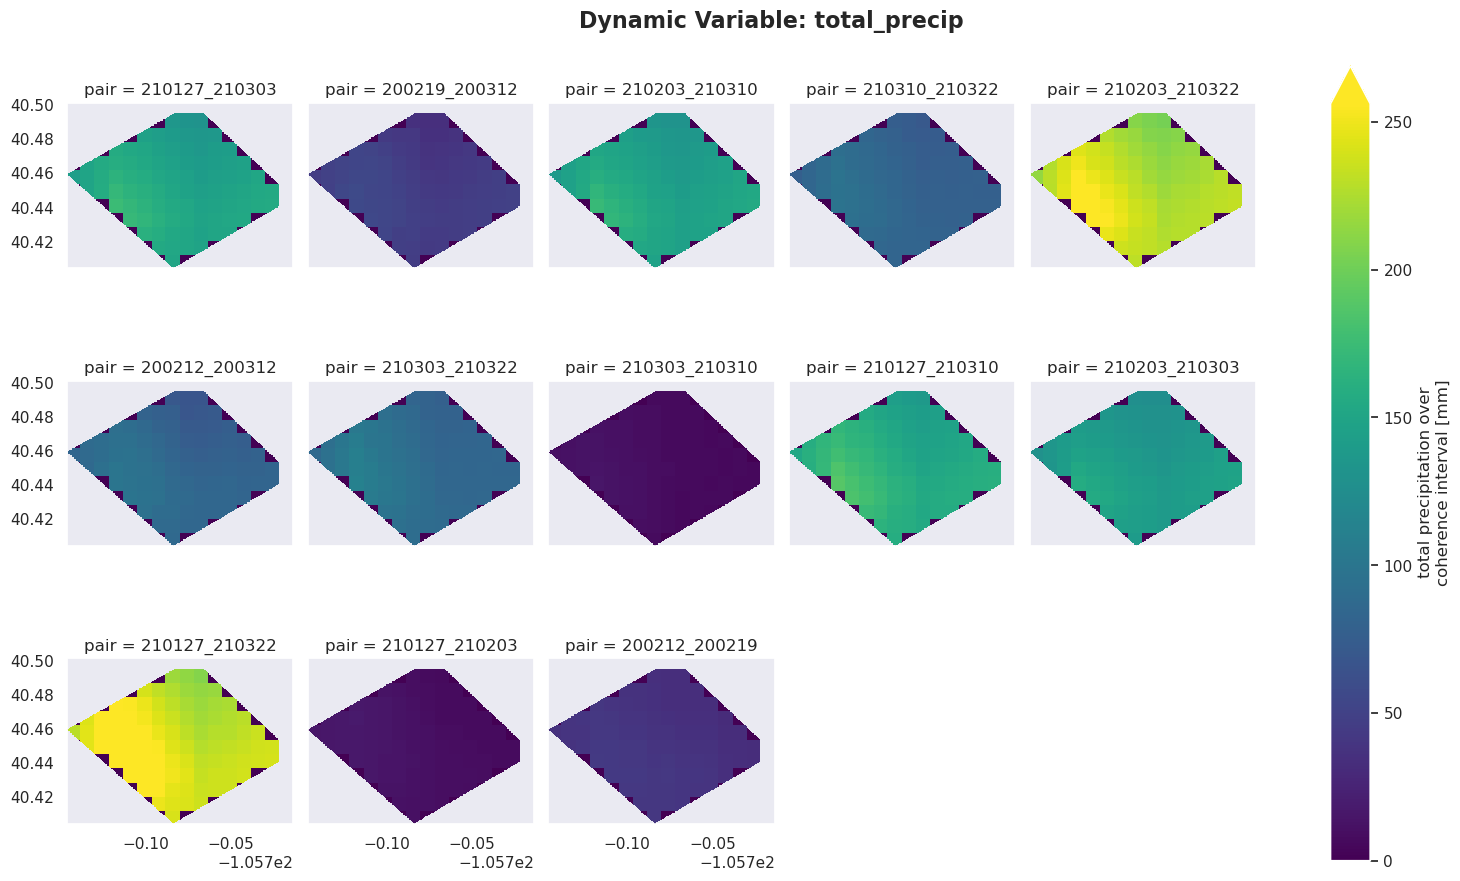

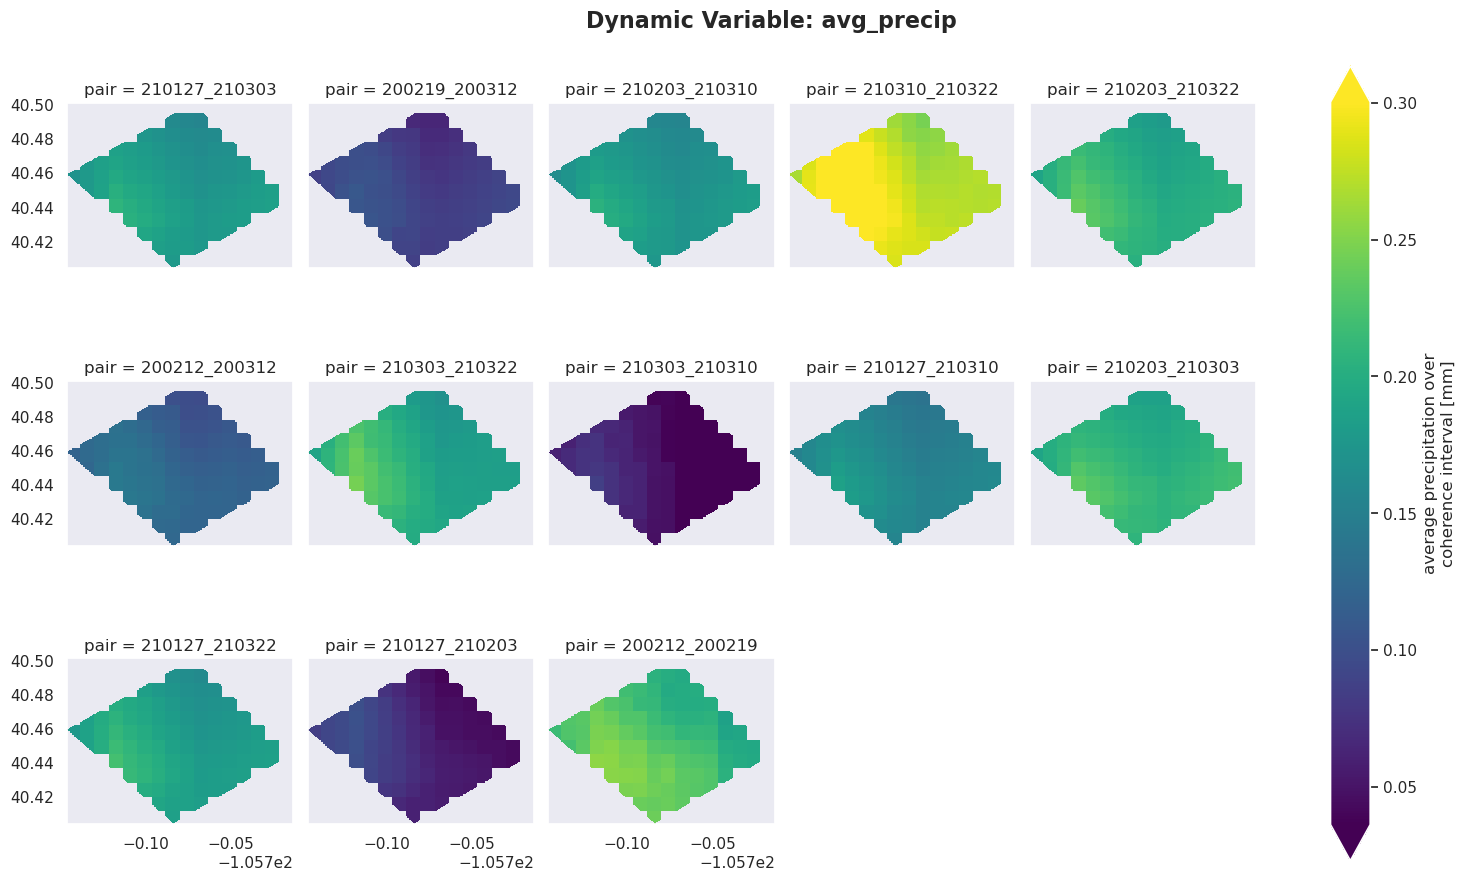

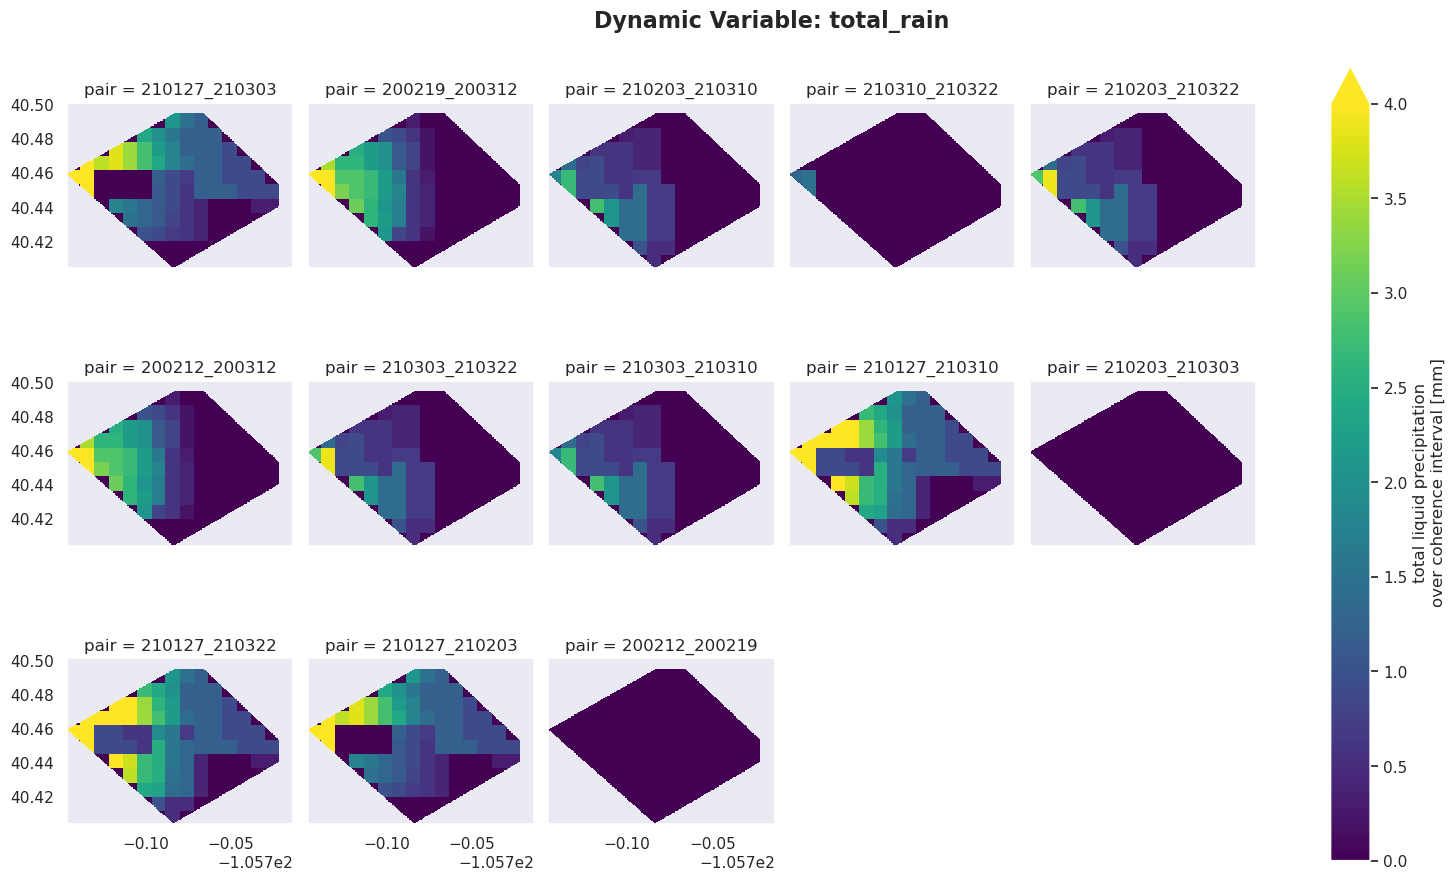

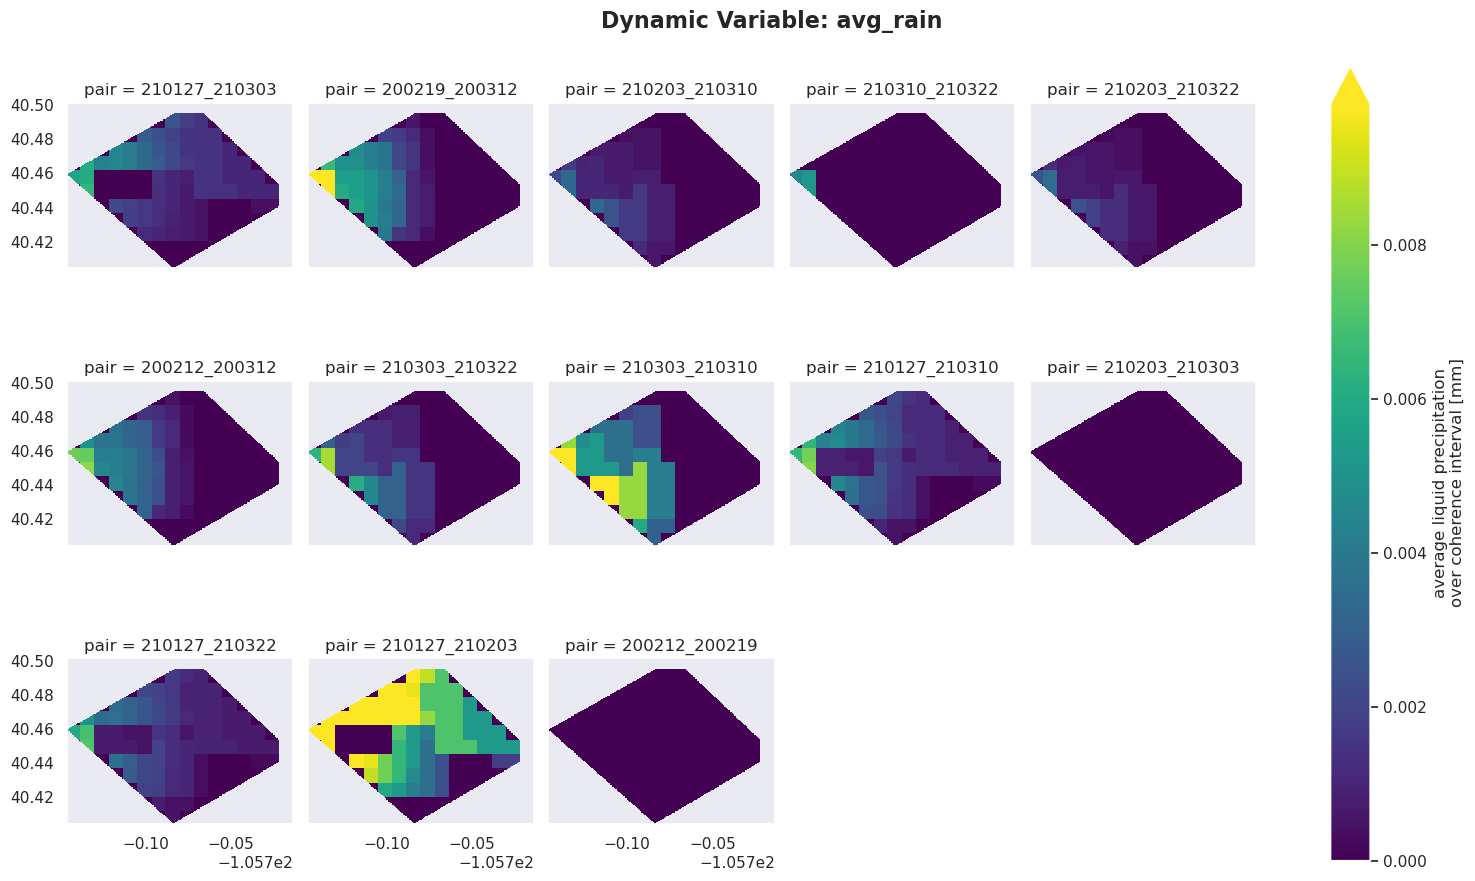

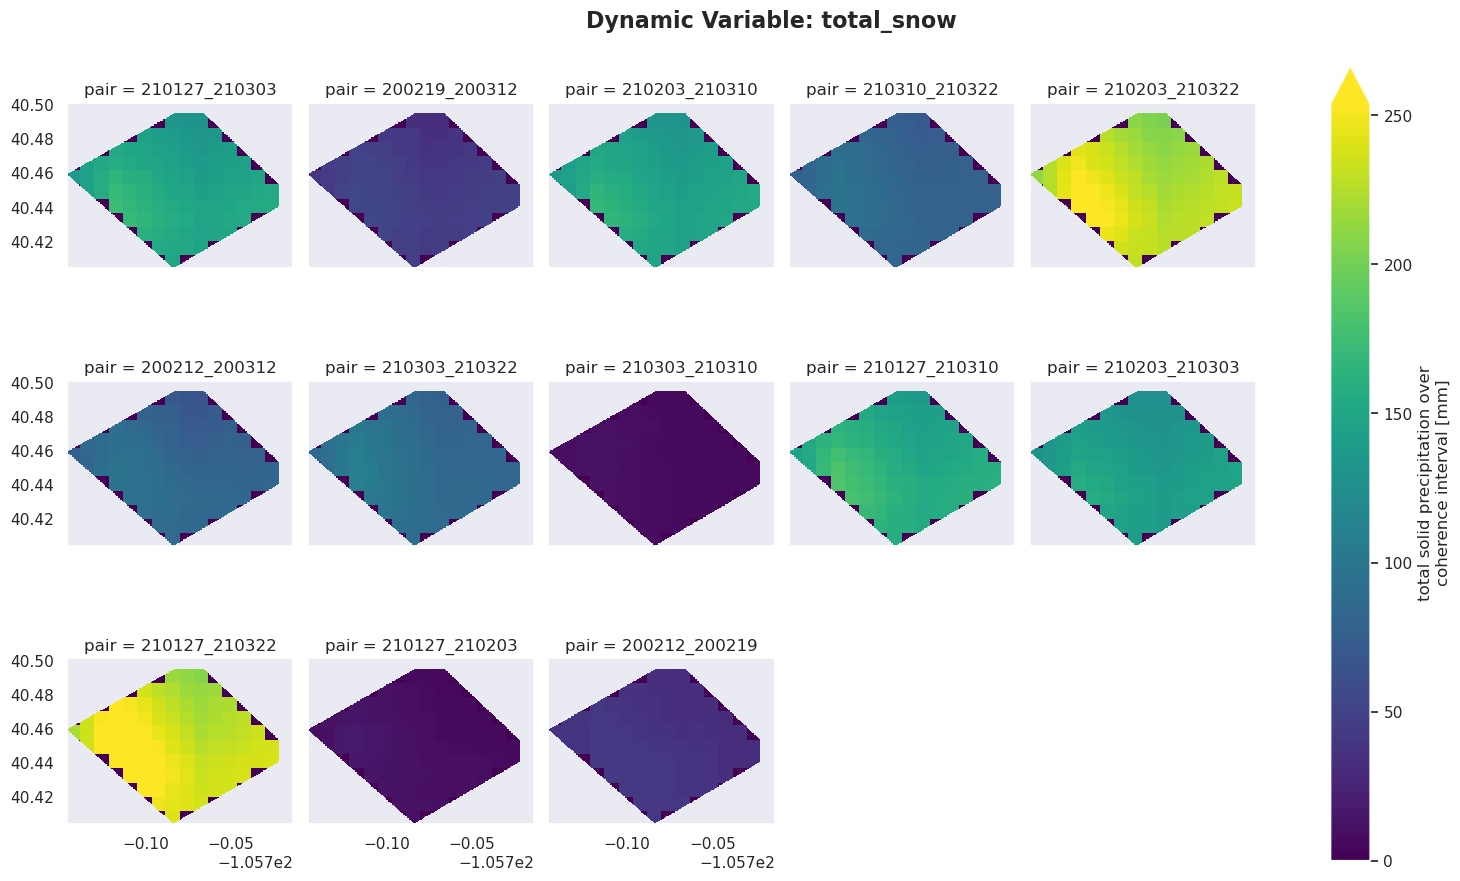

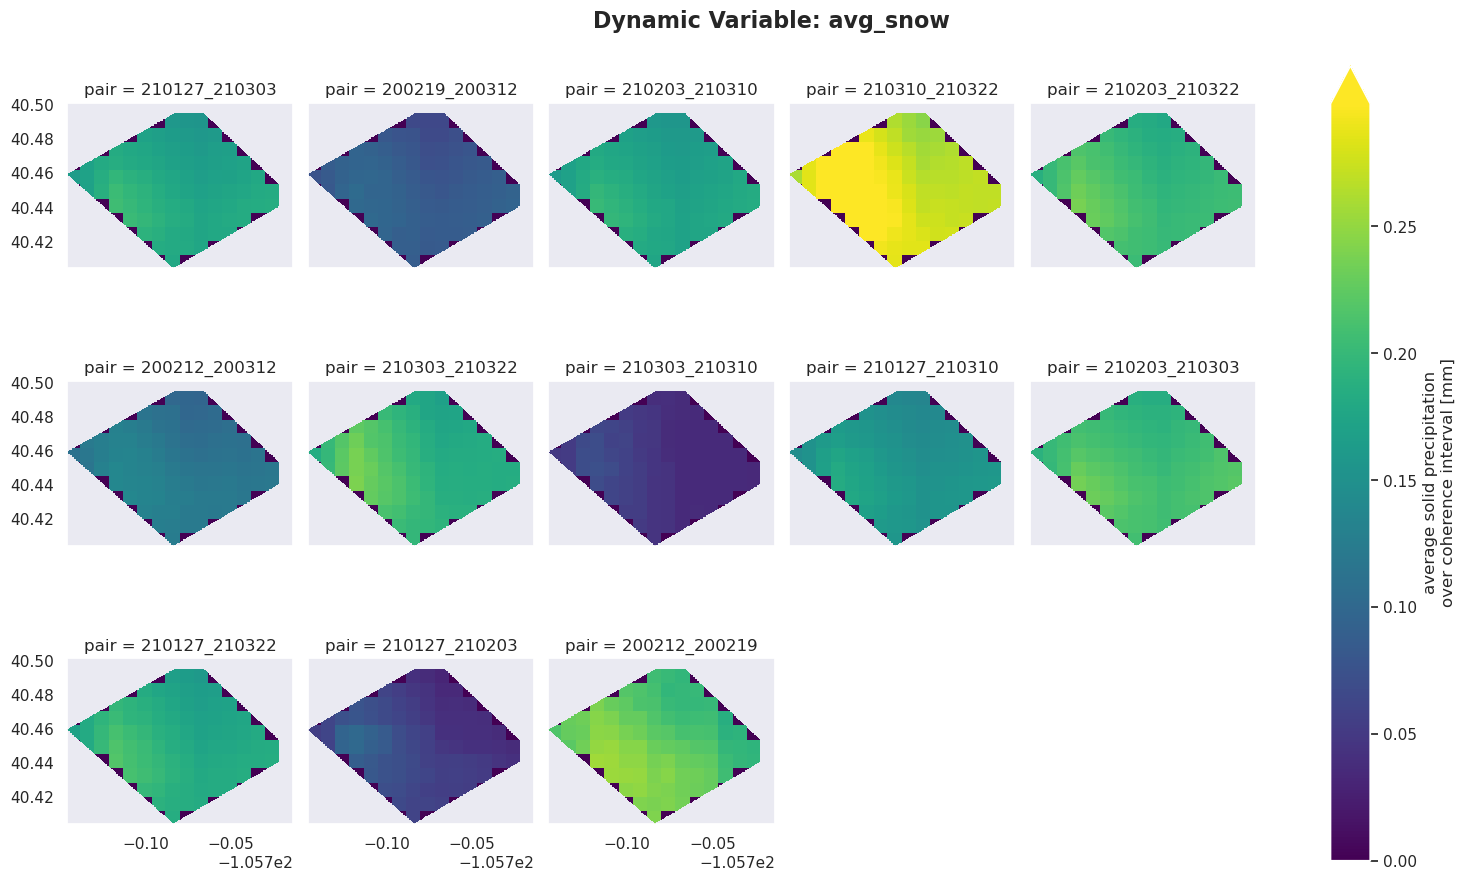

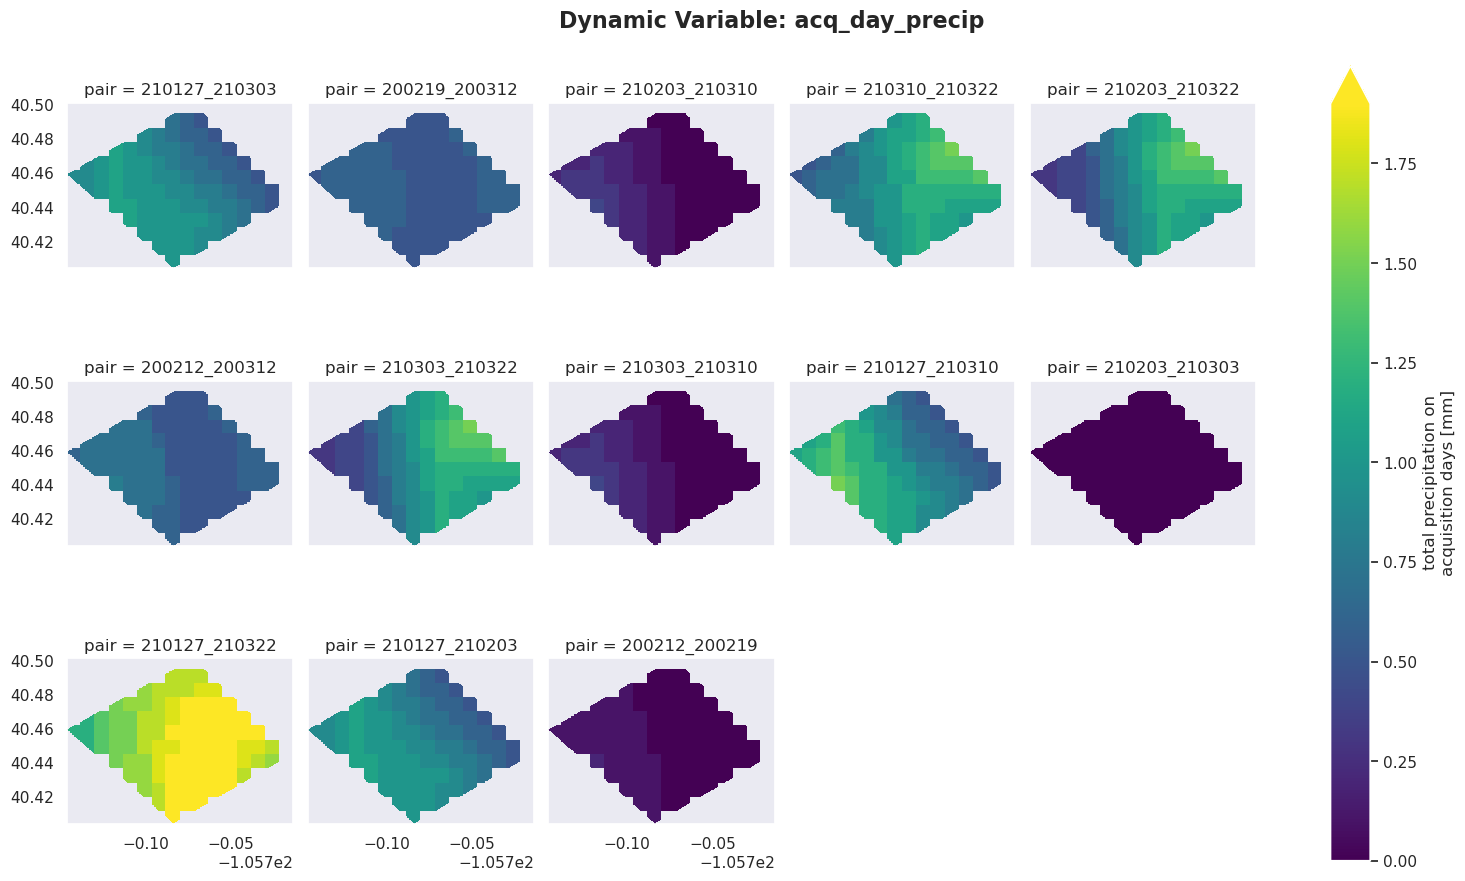

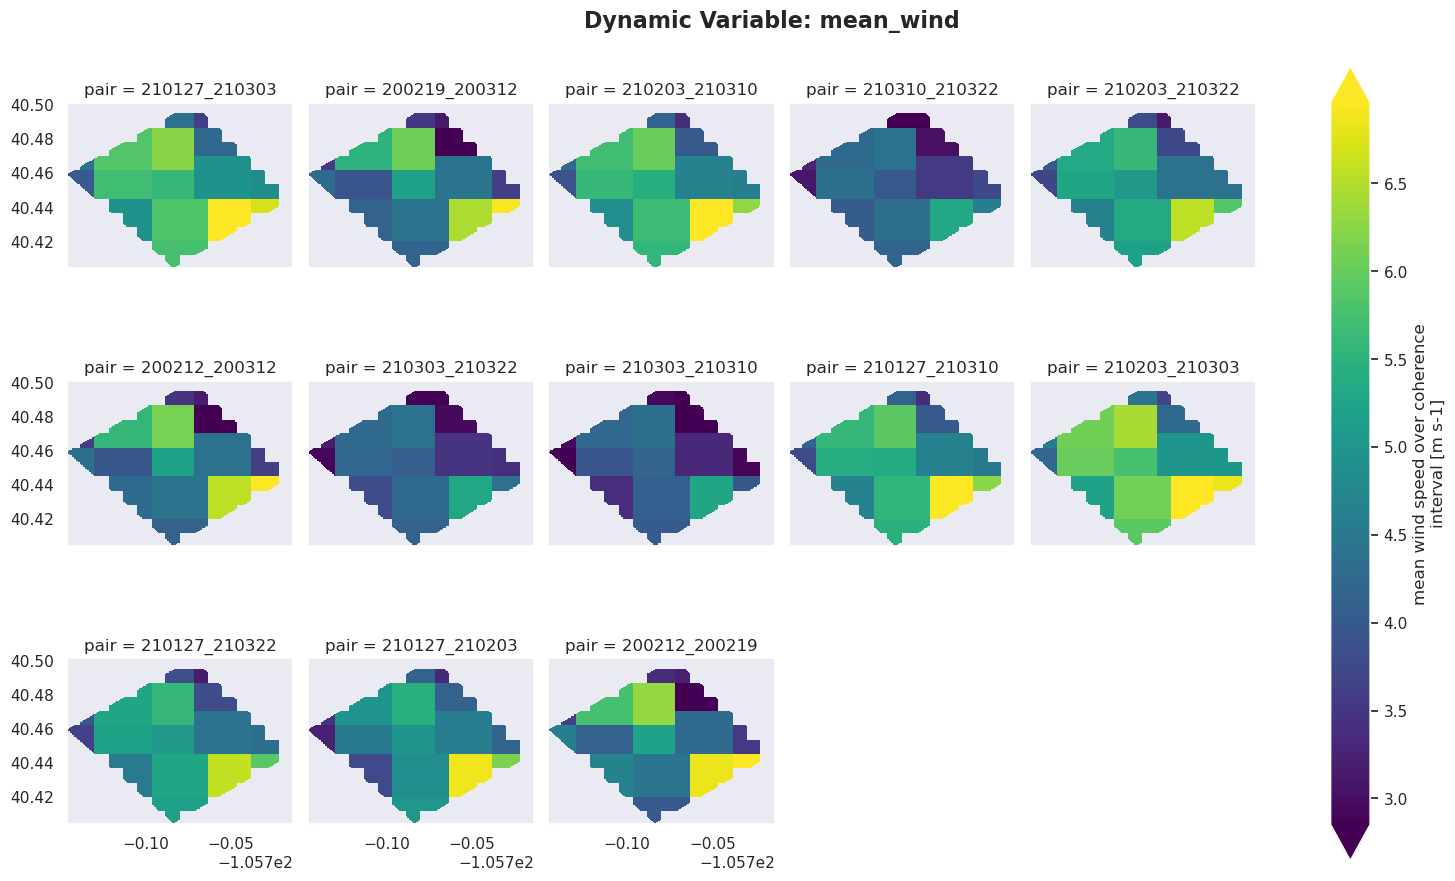

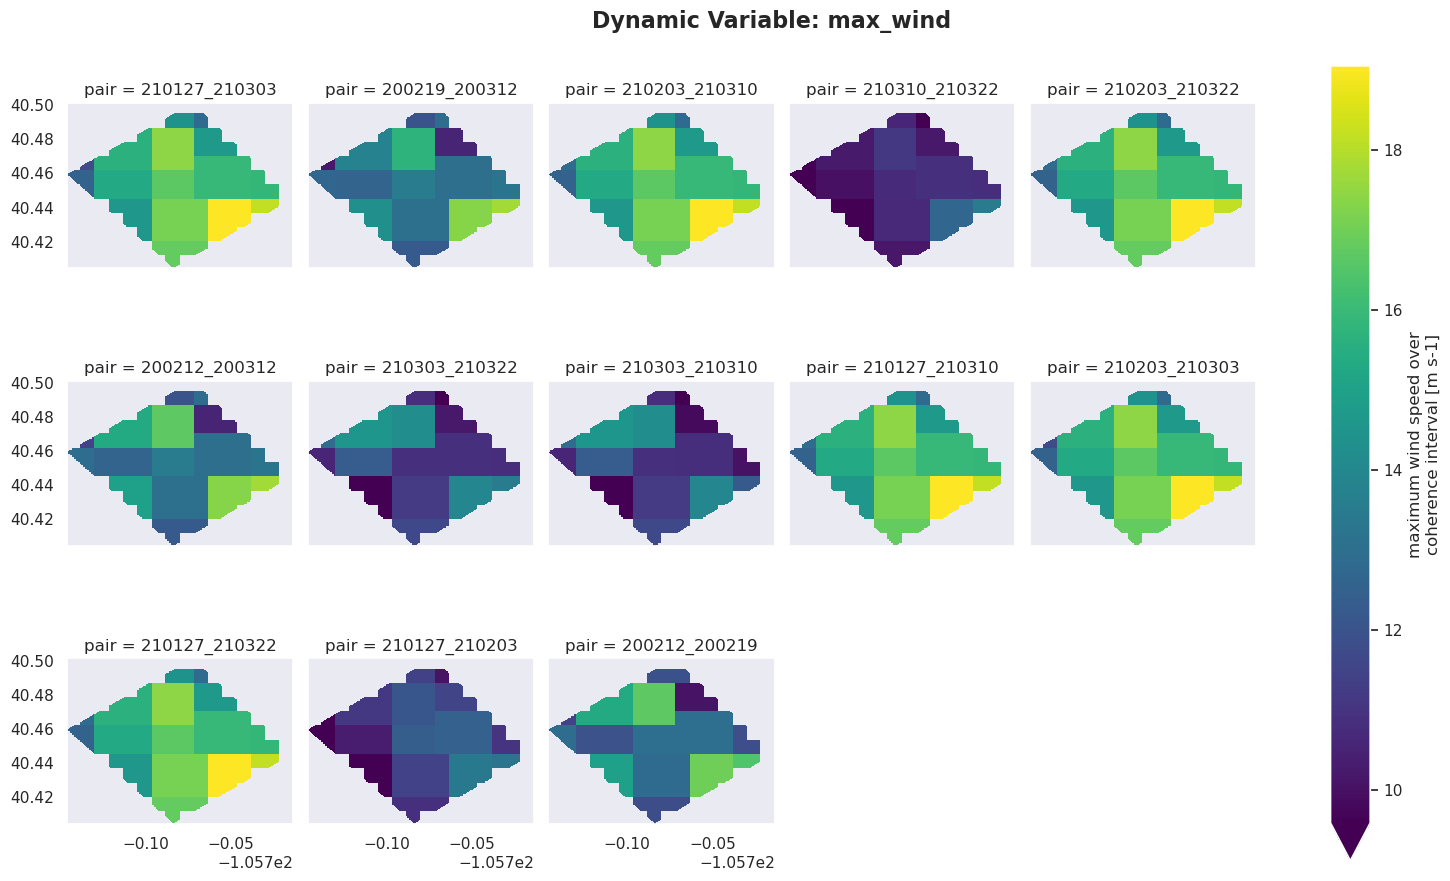

In [51]:
# 1. Separate variables into two lists based on their dimensions
static_vars = [var for var in data.data_vars if 'pair' not in data[var].dims]
pair_vars = [var for var in data.data_vars if 'pair' in data[var].dims]

# ==========================================
# 2. PLOT STATIC VARIABLES (Single Dashboard)
# ==========================================
n_static = len(static_vars)
cols = 3
rows = int(np.ceil(n_static / cols))

# Create one figure for all static variables
fig_static, axes_static = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes_static = axes_static.flatten()

for i, var in enumerate(static_vars):
    ax = axes_static[i]
    
    if var in 'aspect' : cmap = 'twilight'  # cyclic colormap for aspect
    elif var in ['snow_class', 'cover_2019']: cmap = 'tab10'  # categorical colormap for classes
    elif var in 'incidence_angle': cmap = 'viridis_r'
    else: cmap = 'viridis'  # standard colormap for other variables

    # robust=True drops top/bottom 2% of extreme values for a prettier color stretch
    data[var].plot(ax=ax, robust=True, cmap=cmap) 

    
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal') # Keeps pixels square since this is spatial data

# Hide any empty subplots if n_static doesn't divide perfectly by 3
for j in range(i + 1, len(axes_static)):
    axes_static[j].set_visible(False)

fig_static.suptitle('Static Site Variables (2019/Topography)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


# ==========================================
# 3. PLOT DYNAMIC VARIABLES (One Figure Each)
# ==========================================
for var in pair_vars:
    # Pick a diverging colormap for 'change' variables, standard for others
    cmap = 'RdBu' if 'change' in var else 'viridis'
    
    # Xarray automatically creates a multi-panel figure when you use col=
    # plot only nearest_dates
    fg = data[var].plot(
        col='pair',
        col_wrap=5,  # 5 plots per row looks nice for 45 pairs
        # figsize=(15, 3 * int(np.ceil(len(data[var].sizes) / 5))),
        robust=True,
        cmap=cmap
    )

    # fg = data[var].plot(
    #     col='pair',
    #     col_wrap=5,  # 5 plots per row looks nice for 45 pairs
    #     figsize=(15, 3 * int(np.ceil(data.sizes['pair'] / 5))),
    #     robust=True,
    #     cmap=cmap
    # )
    
    # Add a main title for this specific variable's figure
    fg.fig.suptitle(f'Dynamic Variable: {var}', fontsize=16, fontweight='bold', y=1.02)
    
    # Clean up the individual axes
    for ax in fg.axs.flat:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_aspect('equal')
        
    plt.show()

## Filter the data down

In [88]:
# find good pixels 

condition = (data['incidence_angle'] < 80) & \
            (data['canopy_2019'] < 30) & \
            (data['elevation'] > 3400)
            # (data['cover_2019'] > 50) & (data['cover_2019'] < 80) & \
data_good = data.where(condition)

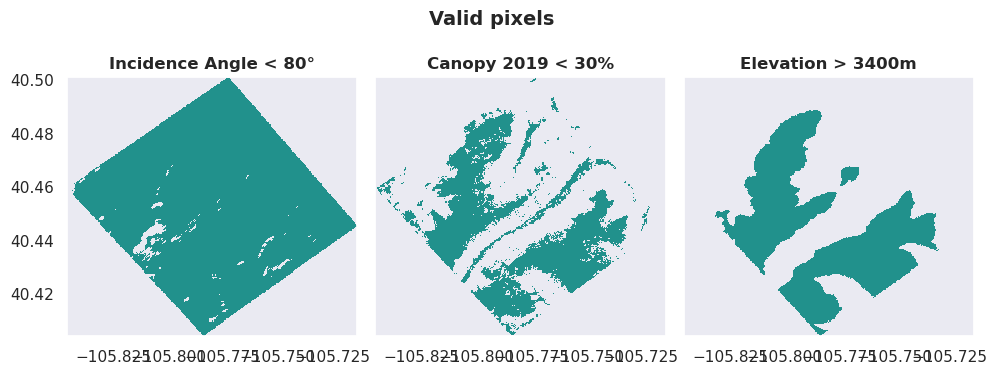

In [93]:
conditions = {
    "Incidence Angle < 80°": data['incidence_angle'] < 80,
    "Canopy 2019 < 30%": data['canopy_2019'] < 30,
    # "Cover 2019 (Shrubs)": (data['cover_2019'] > 50) & (data['cover_2019'] < 80),
    "Elevation > 3400m": data['elevation'] > 3400
}

# 2. Set up a 2x2 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)
axes = axes.ravel()  # Flatten the 2x2 grid into a 1D array for easy looping

# 3. Loop through and plot each isolated condition
for i, (title, cond) in enumerate(conditions.items()):
    ax = axes[i]
    
    # Use .where() to keep data where True, and set where False to NaN.
    # We can just plot 'cond' itself, or apply it to a variable like 'coherence'
    # if you want to see the underlying data values that passed.
    masked_slice = cond.where(cond) 
    
    # Squeeze out any extra dimensions (like band/time) if they exist
    masked_slice = masked_slice.squeeze()
    
    # Plot using xarray's native plotting wrapper, matching your style
    masked_slice.plot(
        ax=ax,
        cmap='viridis',     # Viridis will color the 'True' pixels
        add_colorbar=False
    )
    
    # Clean up the subplot
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')  # Remove repetitive x/y labels if sharing axes
    ax.set_ylabel('')

# Add a main title and clean up layout
plt.suptitle("Valid pixels", 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [76]:
def plot_cube_vs_target(ds: xr.Dataset, target_var: str = 'coherence', ncols: int = 5, gridsize: int = 50):
    """
    Plots variables in an xarray Dataset against a target variable using hexbin density plots.
    
    Parameters:
    - ds: xarray.Dataset containing the data cube.
    - target_var: The variable to plot on the y-axis (default: 'coherence').
    - ncols: Number of columns for the subplot grid (default: 5).
    - gridsize: The number of hexagons in the x-direction (default: 50).
    """
    # 1. Identify variables to plot (exclude the target variable itself)
    if target_var not in ds.data_vars:
        raise ValueError(f"Target variable '{target_var}' not found in the dataset.")
        
    vars_to_plot = [var for var in ds.data_vars if var != target_var]
    n_vars = len(vars_to_plot)
    
    # Calculate required rows based on number of variables and requested columns
    nrows = math.ceil(n_vars / ncols)
    
    # 2. Flatten Data: Convert to DataFrame and drop NaNs
    # We only convert the variables we actually need to save memory
    cols_to_keep = vars_to_plot + [target_var]
    df = ds[cols_to_keep].to_dataframe().dropna()
    
    # 3. Setup the figure
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    
    # Flatten axes array for easy 1D iteration (handles cases where nrows=1 or ncols=1)
    if n_vars == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
        
    # 4. Generate the Hexbin Plots
    for i, var in enumerate(vars_to_plot):
        ax = axes[i]
        
        # Create the hexbin plot
        hb = ax.hexbin(
            x=df[var], 
            y=df[target_var], 
            gridsize=gridsize, 
            cmap='viridis', 
            mincnt=1,      # Only color hexagons that contain at least 1 point
            # bins='log'     # Use logarithmic color scaling for highly dense data
        )
        
        ax.set_xlabel(var)
        ax.set_ylabel(target_var)
        ax.set_title(f'{var} vs {target_var}')
        
        # Add a localized colorbar for each subplot
        cb = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)
        # cb.set_label('log10(N)')
        
    # Hide any leftover empty subplots in the grid
    for j in range(n_vars, len(axes)):
        axes[j].set_visible(False)
        
    plt.tight_layout()
    plt.show()
    
    # 5. Memory Cleanup
    # Explicitly delete the large DataFrame and force python to run garbage collection
    del df

In [69]:
pair_variables = [var for var in data_good.data_vars if 'pair' in data_good[var].dims]
ds_temporal = data_good[pair_variables]

# 2. Sort the pairs chronologically so the time series flows correctly
ds_temporal = ds_temporal.sortby('pair')

# 3. Calculate the median across spatial dimensions (x, y) 
# and squeeze out the single flight_id dimension
ds_reduced = ds_temporal.median(dim=['x', 'y']).squeeze()

# 4. Drop non-essential coordinates and convert to a clean Pandas DataFrame
coords_to_drop = [c for c in ds_reduced.coords if c != 'pair']
df_medians = ds_reduced.drop_vars(coords_to_drop).to_dataframe()

# Inspect the dataframe to make sure it looks like a clean table
df_medians

,coherence,mean_temp,max_temp,total_precip,avg_precip,total_rain,avg_rain,total_snow,avg_snow,acq_day_precip,mean_wind,max_wind
pair,,,,,,,,,,,,
200212_200219,0.497894,-11.042304,1.050004,39.200001,0.231953,0.0,0.000000,39.200001,0.231953,0.0,4.689885,14.932515
200212_200312,0.345693,-8.527041,6.350004,85.500001,0.122669,0.4,0.000574,84.900001,0.121808,0.6,4.422024,14.932515
200219_200312,0.390862,-7.784779,6.350004,47.000001,0.089414,0.4,0.000756,46.800001,0.088469,0.5,4.435787,13.793114
210127_210203,0.613814,-6.710351,3.750004,11.100000,0.065680,0.4,0.002367,10.200000,0.060355,1.0,4.986361,11.469089
210127_210303,0.340956,-9.741554,3.750004,152.600002,0.181807,0.4,0.000476,152.200002,0.180975,1.0,5.836228,16.786900
210127_210310,0.347893,-8.585279,5.750004,160.100002,0.158771,0.9,0.000892,159.300002,0.157879,1.1,5.546262,16.786900
210127_210322,0.275205,-8.188238,8.250004,242.700004,0.187587,0.9,0.000694,241.400004,0.186122,1.7,5.278460,16.786900
210203_210303,0.375671,-10.522953,3.550004,141.700002,0.211441,0.0,0.000000,141.700002,0.210550,0.0,6.073302,16.786900
210203_210310,0.363645,-8.979604,5.750004,150.000002,0.178359,0.5,0.000595,149.400002,0.177646,0.1,5.684451,16.786900


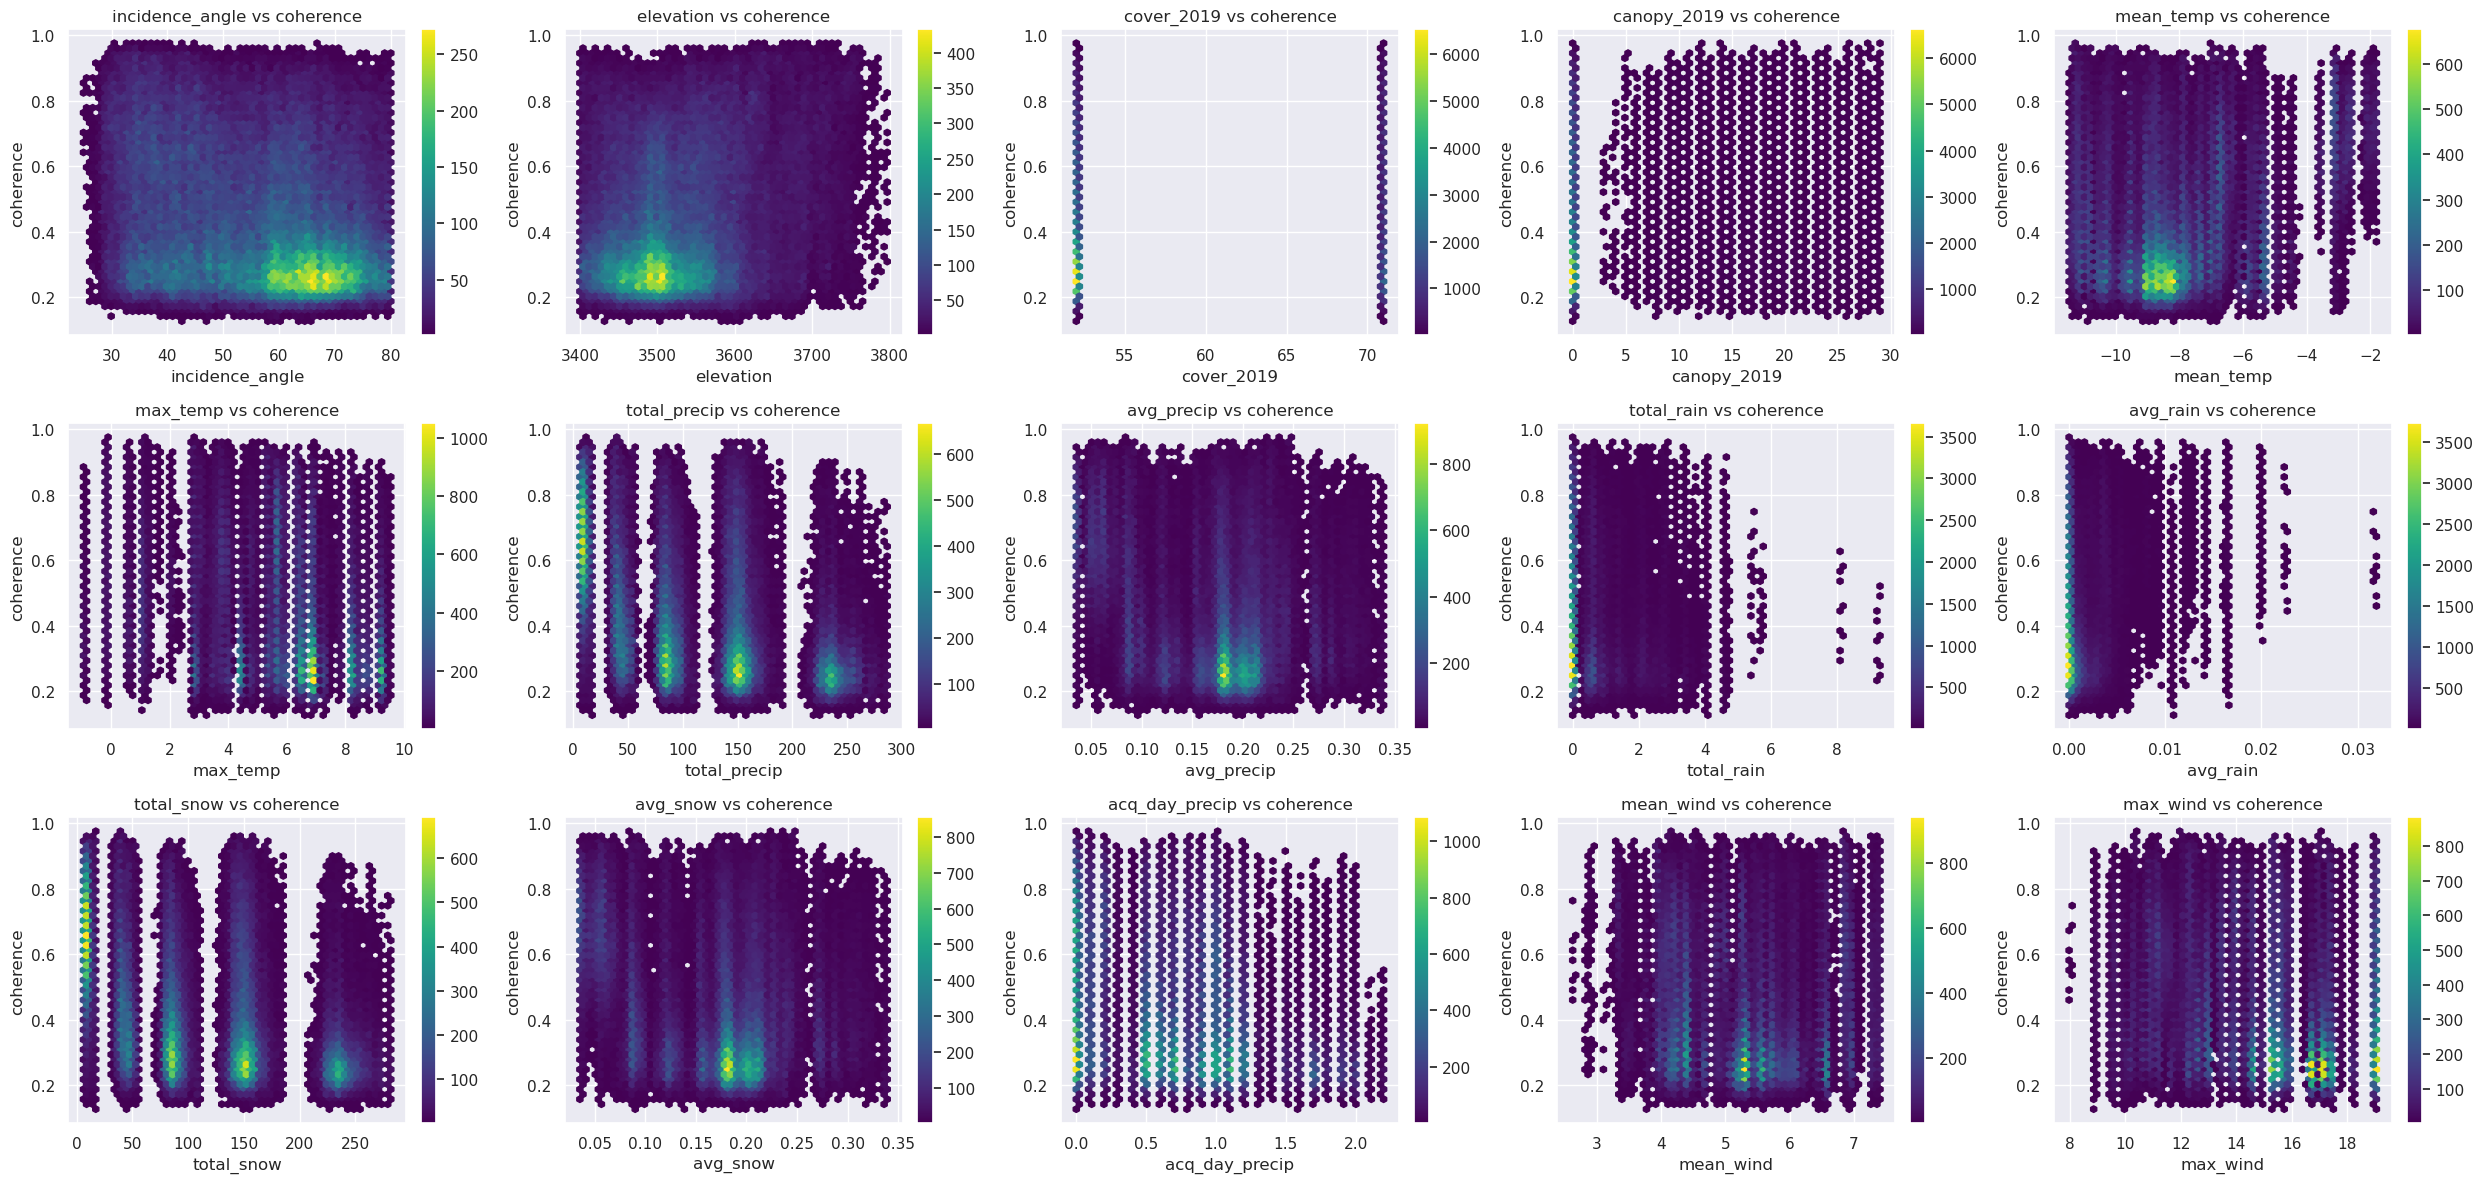

In [77]:
plot_cube_vs_target(data_good)

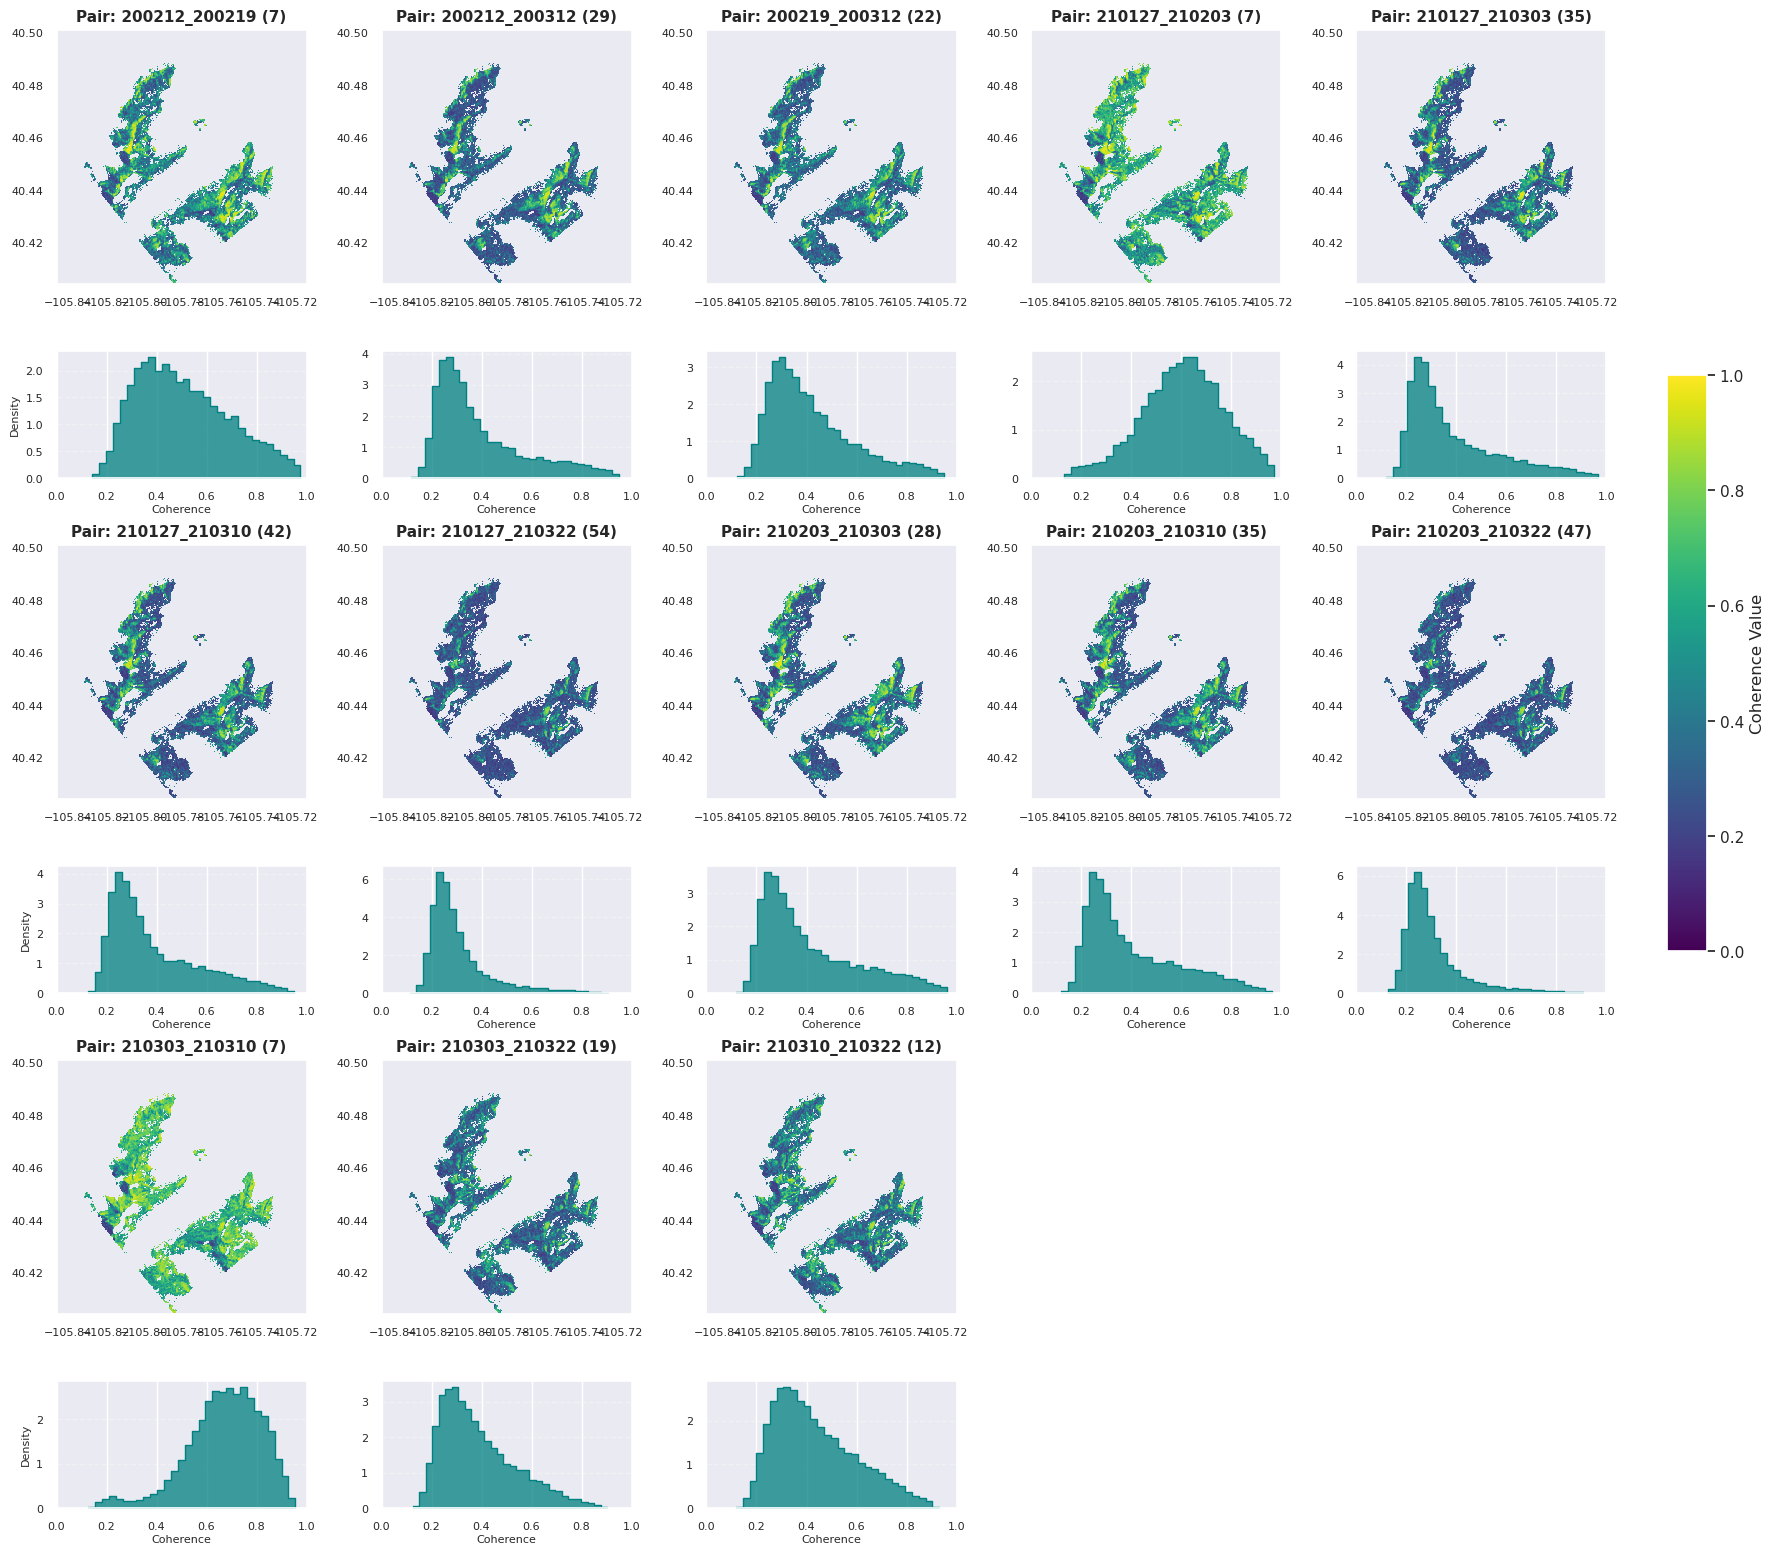

In [100]:
ds_sorted = data_good.sortby('pair')
pairs = ds_sorted.pair.values
num_pairs = len(pairs)

# 2. Configure the 5-column grid layout
ncols = 5
num_groups = (num_pairs + ncols - 1) // ncols
nrows = num_groups * 2 

# --- THE FIX: Create alternating height ratios (Map = 2, Hist = 1) ---
# For 3 groups (6 rows), this generates: [2, 1, 2, 1, 2, 1]
row_height_ratios = []
for _ in range(num_groups):
    row_height_ratios.extend([2, 1])

# Create the master canvas using the new height ratios
fig, axes = plt.subplots(
    nrows=nrows, 
    ncols=ncols, 
    figsize=(4 * ncols, 3.2 * nrows), # Slightly reduced multiplier to account for shorter hists
    gridspec_kw={
        'hspace': 0.35, 
        'wspace': 0.3,
        'height_ratios': row_height_ratios  # <-- Directly scales row heights
    }
)

# 3. Loop through every pair and assign them to the correct grid slots
for idx, pair_name in enumerate(pairs):
    col = idx % ncols
    group = idx // ncols
    row_map = group * 2
    row_hist = (group * 2) + 1
    
    ax_map = axes[row_map, col]
    ax_hist = axes[row_hist, col]
    
    # Extract the 2D spatial slice for this specific pair
    coh_slice = ds_sorted['coherence'].sel(pair=pair_name).squeeze()
    
    # --- TOP PLOT: Spatial Map ---
    coh_slice.plot(
        ax=ax_map, 
        cmap='viridis', 
        vmin=0, 
        vmax=1, 
        add_colorbar=False
    )
    t1, t2 = [datetime.strptime(d, "%y%m%d") for d in pair_name.split("_")]
    # Calculate the difference in days
    days_elapsed = (t2 - t1).days
    ax_map.set_title(f"Pair: {pair_name} ({days_elapsed})", fontsize=11, fontweight='bold')
    ax_map.set_xlabel("")
    ax_map.set_ylabel("")
    ax_map.tick_params(labelsize=8)
    
    # --- BOTTOM PLOT: Histogram (Half Height) ---
    flattened_vals = coh_slice.values.flatten()
    clean_vals = flattened_vals[~np.isnan(flattened_vals)]
    
    sns.histplot(
        clean_vals, 
        bins=30, 
        kde=False, 
        ax=ax_hist, 
        color='teal', 
        element='step',
        stat='density'
    )
    ax_hist.set_xlim(0, 1)
    ax_hist.set_xlabel("Coherence", fontsize=8, labelpad=2)
    ax_hist.set_ylabel("Density" if col == 0 else "", fontsize=8)
    ax_hist.tick_params(labelsize=8)
    ax_hist.grid(axis='y', linestyle='--', alpha=0.3)

# 4. Clean up and delete any empty subplot slots in the final row group
for blank_idx in range(idx + 1, num_groups * ncols):
    b_col = blank_idx % ncols
    b_group = blank_idx // ncols
    
    fig.delaxes(axes[b_group * 2, b_col])     
    fig.delaxes(axes[(b_group * 2) + 1, b_col]) 

# 5. Add a single, unified colorbar on the right side of the entire figure
mappable = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=1))
cbar_ax = fig.add_axes([0.93, 0.4, 0.02, 0.3]) 
fig.colorbar(mappable, cax=cbar_ax, label='Coherence Value')

plt.suptitle("", fontsize=16, fontweight='bold', y=0.99)
plt.show()


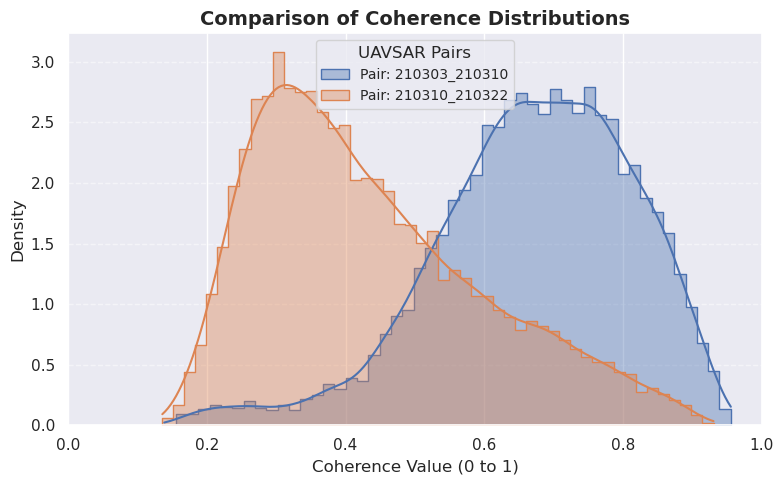

In [72]:
chosen_pairs = ['210303_210310', '210310_210322'] 

plt.figure(figsize=(8, 5))

# 2. Loop through each chosen pair and plot its distribution
for pair_name in chosen_pairs:
    # .sel() extracts the specific pair
    # .squeeze() removes the single-value 'flight_id' dimension
    # .values gets the raw numpy array
    pixel_data = data_good['coherence'].sel(pair=pair_name).squeeze().values
    
    # Flatten the 2D (y, x) array into a 1D vector of numbers
    flattened_vals = pixel_data.flatten()
    
    # CRITICAL: Drop NaN values (pixels outside the flight track/AOI)
    clean_vals = flattened_vals[~np.isnan(flattened_vals)]
    
    # 3. Plot the distribution
    sns.histplot(
        clean_vals,
        kde=True,            # Adds a smooth kernel density estimate curve
        label=f"Pair: {pair_name}",
        alpha=0.4,           # Transparency (0 = invisible, 1 = solid)
        bins=50,             # Number of bins between 0 and 1
        element="step",      # 'step' style looks cleaner when overlapping
        stat="density"       # Normalizes count if pairs have different pixel counts
    )

# 4. Format and style the plot
plt.title("Comparison of Coherence Distributions", fontsize=14, fontweight='bold')
plt.xlabel("Coherence Value (0 to 1)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Coherence is theoretically strictly bounded between 0 and 1
plt.xlim(0, 1) 

plt.legend(title="UAVSAR Pairs", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()